<a href="https://colab.research.google.com/github/aadityaakarna/TRANSFER-LEARNING/blob/main/Transferlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


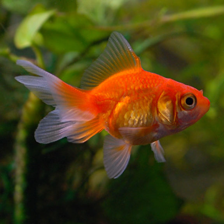

In [11]:
from PIL import Image
IMAGE_SHAPE=(224,224)
gold_fish = Image.open("goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [12]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [13]:
gold_fish[np.newaxis, ...]


array([[[[0.28235294, 0.33333333, 0.07058824],
         [0.31372549, 0.37254902, 0.09019608],
         [0.34901961, 0.41960784, 0.11764706],
         ...,
         [0.32941176, 0.39215686, 0.00392157],
         [0.32156863, 0.38431373, 0.00392157],
         [0.30980392, 0.36862745, 0.        ]],

        [[0.28627451, 0.33333333, 0.08235294],
         [0.3254902 , 0.38039216, 0.10980392],
         [0.35294118, 0.42352941, 0.12941176],
         ...,
         [0.32156863, 0.38039216, 0.00392157],
         [0.31372549, 0.37254902, 0.00392157],
         [0.30196078, 0.36078431, 0.        ]],

        [[0.28627451, 0.33333333, 0.08627451],
         [0.31372549, 0.36862745, 0.10196078],
         [0.34509804, 0.41568627, 0.12941176],
         ...,
         [0.31764706, 0.37647059, 0.00392157],
         [0.30980392, 0.36862745, 0.00784314],
         [0.29803922, 0.35686275, 0.00392157]],

        ...,

        [[0.05490196, 0.10980392, 0.01568627],
         [0.05098039, 0.11372549, 0.01960784]

In [15]:
result = base_model.predict(gold_fish[np.newaxis, ...])
result.shape



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(1, 7, 7, 1280)

In [16]:
predicted_label_index = np.argmax(result)
predicted_label_index

np.int64(3125)

In [18]:
image_labels = []
with open("ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [20]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [21]:
import pathlib
data_dir=pathlib.Path(data_dir)
data_dir
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"

print("Dataset Path:", data_dir)
print("Folders:", os.listdir(data_dir))

Dataset Path: datasets/flower_photos/flower_photos
Folders: ['daisy', 'sunflowers', 'dandelion', 'tulips', 'LICENSE.txt', 'roses']


In [22]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [23]:
roses = list(data_dir.glob('roses/*'))
m
print(len(roses))

641


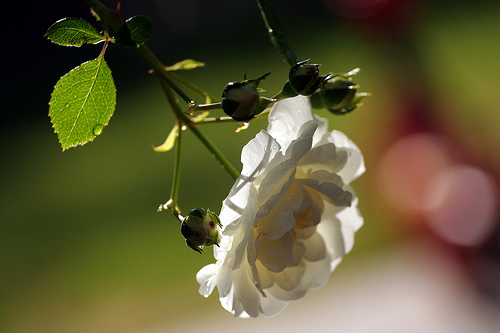

In [26]:
import PIL
PIL.Image.open(str(roses[0]))

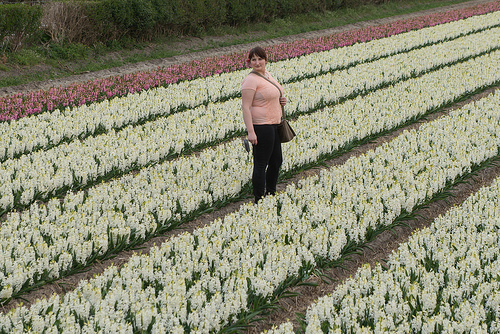

In [27]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [28]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [29]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [30]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/3560426426_1c66cb8330.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/873660804_37f5c6a46e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5402157745_a384f0583d_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15821959372_518b9dcf57_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4713531680_1110a2fa07_n.jpg')]

In [31]:
str(flowers_images_dict['roses'][0])



'datasets/flower_photos/flower_photos/roses/3560426426_1c66cb8330.jpg'

In [32]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [33]:
img.shape

(333, 500, 3)

In [34]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [35]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])


In [36]:
X = np.array(X)
y = np.array(y)

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)


In [38]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [39]:
X[0].shape

(224, 224, 3)

In [40]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [41]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)m


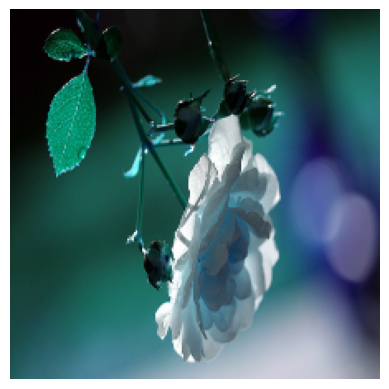

In [42]:
plt.axis('off')
plt.imshow(X[0])

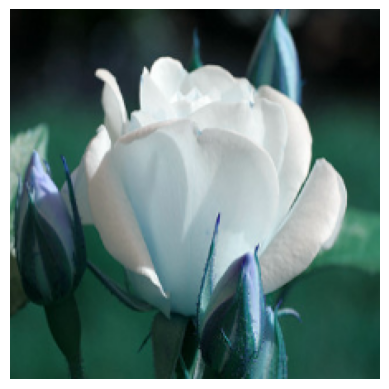

In [43]:
plt.axis('off')
plt.imshow(X[1])

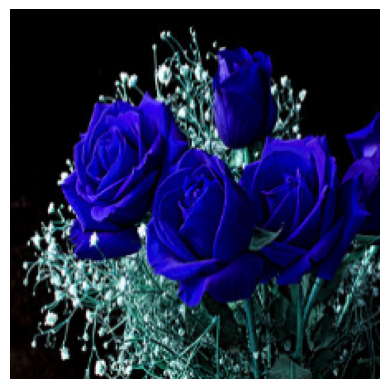

In [44]:
plt.axis('off')
plt.imshow(X[2])

In [45]:
predicted = base_model.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[[0, 1, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 1, 2],
        [0, 4, 4, ..., 0, 1, 1],
        ...,
        [0, 3, 0, ..., 0, 2, 3],
        [0, 2, 0, ..., 0, 0, 3],
        [0, 3, 0, ..., 0, 0, 3]],

       [[0, 2, 0, ..., 0, 0, 2],
        [0, 2, 0, ..., 0, 0, 2],
        [0, 2, 0, ..., 0, 0, 3],
        ...,
        [0, 2, 0, ..., 0, 0, 3],
        [0, 1, 0, ..., 0, 0, 3],
        [0, 2, 0, ..., 0, 0, 3]],

       [[4, 2, 1, ..., 0, 0, 0],
        [3, 2, 1, ..., 1, 2, 0],
        [0, 1, 4, ..., 3, 2, 3],
        ...,
        [0, 0, 4, ..., 2, 0, 0],
        [5, 0, 4, ..., 2, 4, 2],
        [0, 2, 5, ..., 3, 0, 0]]])

In [46]:
image_labels[795]

'shower curtain'

In [50]:
pretrained_model_without_top_layer = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze all pretrained weights
pretrained_model_without_top_layer.trainable = False

In [51]:
num_of_flowers = 5

model = tf.keras.Sequential([
    pretrained_model_without_top_layer,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(num_of_flowers)
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [52]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - acc: 0.6875 - loss: 0.8304
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - acc: 0.8405 - loss: 0.4535
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - acc: 0.8717 - loss: 0.3617
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - acc: 0.9004 - loss: 0.3047
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - acc: 0.9128 - loss: 0.2673


In [53]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - acc: 0.8682 - loss: 0.3752


[0.37521257996559143, 0.8681917190551758]